/tmp/ipykernel_7224/1159714633.py:67: RuntimeWarning: Mean of empty slice
  center_x = x[core_nodes].mean()
/tmp/ipykernel_7224/1159714633.py:68: RuntimeWarning: Mean of empty slice
  center_y = y[core_nodes].mean()
/tmp/ipykernel_7224/1159714633.py:69: RuntimeWarning: Mean of empty slice
  center_z = z[core_nodes].mean()


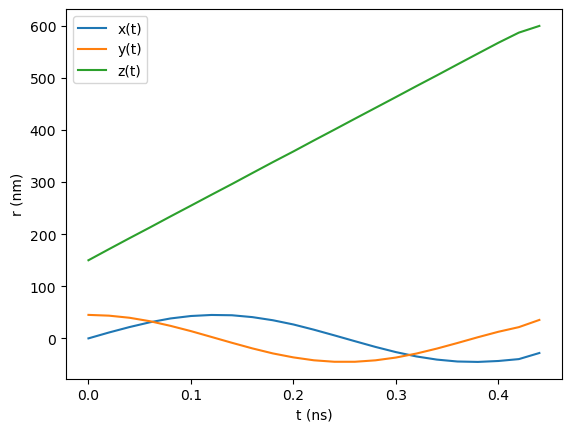

In [6]:
import glob
import re

import h5py
import numpy as np
import matplotlib.pyplot as plt


# LOAD FILES

h5files = sorted(
    glob.glob("STT_lind_gpu/*.h5"),
    key=lambda name: [
        int(token) if token.isdigit() else token.lower()
        for token in re.split(r"(\d+)", name)
    ]
)


trajectory = []

# PROCESS EACH SAVED MAGNETIZATION STATE


for frame, filename in enumerate(h5files):

    with h5py.File(filename, "r") as h5:

        # Mesh coordinates
        points = h5["/Mesh/Grid/geometry"][:]

        # Magnetization field
        magnetization = h5["/Function/f/0"][:]


    # EXTRACT CARTESIAN COMPONENTS

    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    mx = magnetization[:, 0]
    my = magnetization[:, 1]
    mz = magnetization[:, 2]


    # COMPUTE THE LOCAL OUTWARD NORMAL OF THE TORUS


    nx = x / np.sqrt(x*x+y*y)
    ny = y / np.sqrt(x*x+y*y)
    nz = 0.

    # PROJECT THE MAGNETIZATION ONTO THE LOCAL NORMAL
        
    normal_component = mx * nx + my * ny + mz * nz

    # LOCATE THE SKYRMION CORE


    core_nodes = np.where(normal_component <-0.9)[0]


    # SKYRMION CENTER


    center_x = x[core_nodes].mean()
    center_y = y[core_nodes].mean()
    center_z = z[core_nodes].mean()



    trajectory.append([2e-11*1e9*frame,center_x, center_y, center_z])
    
trajectory = np.array(trajectory)

plt.plot(trajectory[:,0],trajectory[:,1], label="x(t)")
plt.plot(trajectory[:,0],trajectory[:,2], label="y(t)")
plt.plot(trajectory[:,0],trajectory[:,3], label="z(t)")
plt.xlabel("t (ns)")
plt.ylabel("r (nm)")
plt.legend()
plt.show()

In [7]:
# We calculate the skyrmion velocity (v_phi, v_z)

time = trajectory[:, 0] 
x = trajectory[:, 1]    
y = trajectory[:, 2]     
z = trajectory[:, 3]    

phi = np.arctan2(y, x)
phi_unwrapped = np.unwrap(phi)

slope_z, intercept_z = np.polyfit(time[:-5], z[:-5], 1)
slope_phi, intercept_phi = np.polyfit(time[:-5], phi_unwrapped[:-5], 1)

print("v_z in m/s is", slope_z)
print("v_phi in m/s is", 50 * np.abs(slope_phi))

v_z in m/s is 1042.0472680278942
v_phi in m/s is 626.0331076380826
